In [3]:
import pandas as pd

In [9]:
df=pd.read_csv('/content/financial_fraud_500.csv',usecols=['Age','AccountBalance','Fraudulent'])
df

,Age,AccountBalance,Fraudulent
0,56,98325,0
1,46,0,1
2,32,41205,0
3,60,59707,0
4,25,52024,0
...,...,...,...
495,37,60516,0
496,41,49442,0
497,29,11616,0
498,52,54504,0


In [10]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5150 - loss: 727.1834 - val_accuracy: 0.8900 - val_loss: 111.2263
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8850 - loss: 229.7167 - val_accuracy: 0.8900 - val_loss: 154.4697
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 232.9383 - val_accuracy: 0.9500 - val_loss: 125.8804
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9025 - loss: 169.5517 - val_accuracy: 0.9500 - val_loss: 75.7952
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9025 - loss: 80.9477 - val_accuracy: 0.9500 - val_loss: 14.0915
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7825 - loss: 38.4213 - val_accuracy: 0.9500 - val_loss: 40.9183
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9025 - loss: 60.0420 - val_accuracy: 0.9500 - val_loss: 23.3017
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8500 - loss: 17.3479 - 

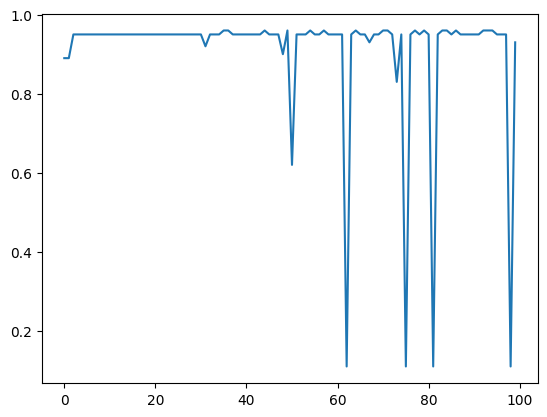

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy']) # Validation accuracy fluctuate too much

## Apply Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7075 - loss: 0.6705 - val_accuracy: 0.8900 - val_loss: 0.6133
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8850 - loss: 0.5735 - val_accuracy: 0.8900 - val_loss: 0.5326
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8850 - loss: 0.5019 - val_accuracy: 0.8900 - val_loss: 0.4718
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8850 - loss: 0.4477 - val_accuracy: 0.8900 - val_loss: 0.4292
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8850 - loss: 0.4108 - val_accuracy: 0.8900 - val_loss: 0.3980
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8850 - loss: 0.3833 - val_accuracy: 0.8900 - val_loss: 0.3750
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8850 - loss: 0.3654 - val_accuracy: 0.8900 - val_loss: 0.3575
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8850 - loss: 0.3518 - val_accuracy: 0.8900 - val_l

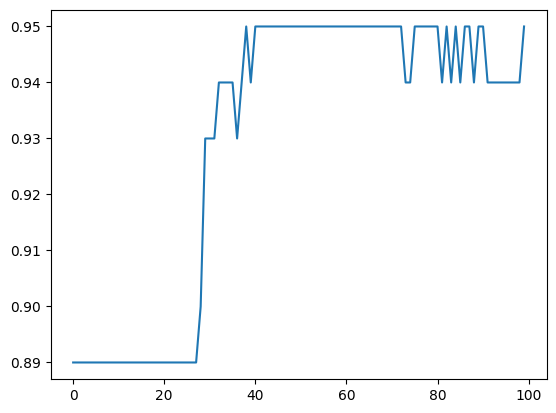

In [20]:
plt.plot(history.history['val_accuracy'])